In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [49]:
cau = [
    "tôi thích uống cà phê vào buổi sáng",
    "cà phê buổi sáng là sở thích của tôi",
    "trời hôm nay mưa rất to",
    "cơn mưa lớn đang tạnh dần",
    "hôm nay tôi đi đến trường bằng xe buýt",
    "tôi dùng xe buýt để đến công ty",
    "cuốn sách này rất đắt",
    "nội dung cuốn sách này thật thú vị"
]
vocab = sorted({w for s in cau for w in s.lower().split()})

In [50]:
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        if w in vocab:
            v[vocab.index(w)] += 1
    return v
X = np.array([to_vector(s) for s in cau])
print(X.shape)

(8, 41)


In [51]:
mean = X.mean(axis=0)
print("mean.shape:", mean.shape)
Xc = X - mean
print("Xc.shape:", Xc.shape)

mean.shape: (41,)
Xc.shape: (8, 41)


In [52]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
    Yn = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-9)
    return Xn @ Yn.T
print(np.round(cosine_similarity(X), 4))
print("Kích thước ma trận:", cosine_similarity(X).shape)

[[1.     0.7071 0.     0.     0.1179 0.125  0.     0.    ]
 [0.7071 1.     0.     0.     0.1111 0.1179 0.     0.    ]
 [0.     0.     1.     0.1667 0.2722 0.     0.1826 0.    ]
 [0.     0.     0.1667 1.     0.     0.     0.     0.    ]
 [0.1179 0.1111 0.2722 0.     1.     0.4714 0.     0.    ]
 [0.125  0.1179 0.     0.     0.4714 1.     0.     0.    ]
 [0.     0.     0.1826 0.     0.     0.     1.     0.4743]
 [0.     0.     0.     0.     0.     0.     0.4743 1.    ]]
Kích thước ma trận: (8, 8)


In [53]:
def search(query, top_k=3):
    q = np.array([to_vector(query)]) 
    sims = cosine_similarity(X, q).flatten()
    idx = np.argsort(sims)[-top_k:][::-1]
    return [(cau[i], round(float(sims[i]), 3)) for i in idx]
print(search("tôi không thèm uống sữa vào buổi sáng"))

[('tôi thích uống cà phê vào buổi sáng', 0.791), ('cà phê buổi sáng là sở thích của tôi', 0.447), ('tôi dùng xe buýt để đến công ty', 0.158)]


In [54]:
sim_matrix = cosine_similarity(X)
np.fill_diagonal(sim_matrix, -1)
max_idx = np.unravel_index(np.argmax(sim_matrix), sim_matrix.shape)
print(f"Giống nhất: '{cau[max_idx[0]]}' và '{cau[max_idx[1]]}'")
np.fill_diagonal(sim_matrix, 2)
min_idx = np.unravel_index(np.argmin(sim_matrix), sim_matrix.shape)
print(f"Khác nhất: '{cau[min_idx[0]]}' và '{cau[min_idx[1]]}'")

Giống nhất: 'tôi thích uống cà phê vào buổi sáng' và 'cà phê buổi sáng là sở thích của tôi'
Khác nhất: 'tôi thích uống cà phê vào buổi sáng' và 'trời hôm nay mưa rất to'


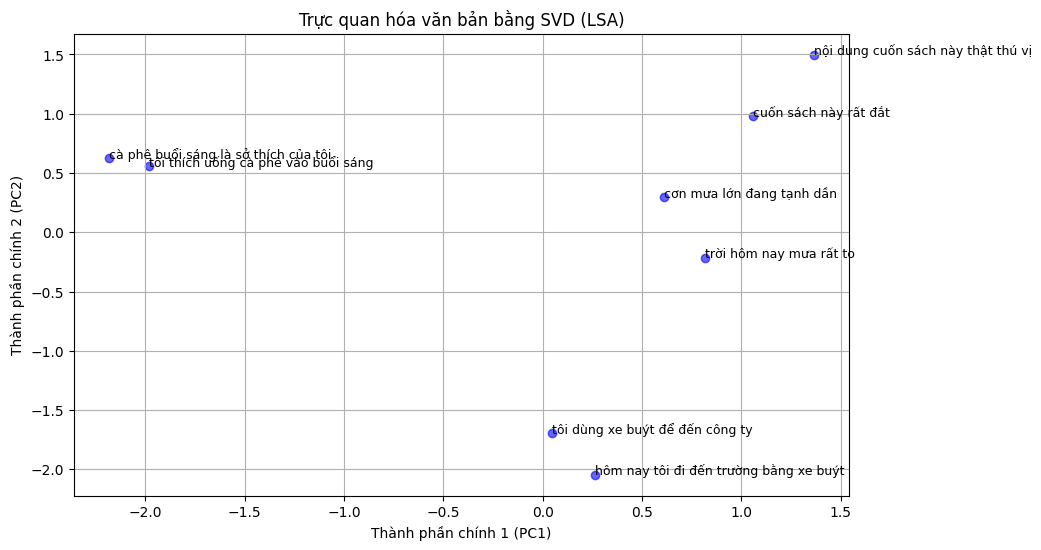

In [56]:
Xc = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:, :2] * S[:2]
plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], c='blue', alpha=0.6)
for i, txt in enumerate(cau):
    plt.annotate(txt, (coords[i, 0], coords[i, 1]), fontsize=9)
plt.title("Trực quan hóa văn bản bằng SVD (LSA)")
plt.xlabel("Thành phần chính 1 (PC1)")
plt.ylabel("Thành phần chính 2 (PC2)")
plt.grid(True)
plt.show()

In [57]:
def cosine_similarity(X, Y):
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
    Yn = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-9)
    return (Xn @ Yn.T).flatten()

def predict_1nn(X_train, y_train, x_query):
    sims = cosine_similarity(X_train, x_query.reshape(1, -1))
    best_idx = np.argmax(sims)
    return y_train[best_idx]

X_train = np.array([[1, 0], [0, 1], [1, 1]])
y_train = np.array(['Loai A', 'Loai B', 'Loai A'])

x_new = np.array([0.9, 0.1])

label = predict_1nn(X_train, y_train, x_new)
print(label)

Loai A
